In [ ]:
%load_ext autoreload
%autoreload 2

# Imports

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd

from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from src.pipelines import (
    create_pipeline,
    create_preprocessor,
    evaluate_model,
    prepare_data,
    save_results,
)

warnings.filterwarnings('ignore', category=UserWarning)

## Data Preparation for Further Work

In [ ]:
raw_df = pd.read_csv(
    "../data/bank-additional-full.csv",
    sep=";"
)

# splitting data into train and validation sets in an 80/20 ratio
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['y'])

train_df = train_df.copy()
val_df = val_df.copy()

# create mapping column 'yes' = 1, 'no' = 0
train_df['y_num'] = train_df['y'].map({'yes': 1, 'no': 0})
val_df['y_num'] = val_df['y'].map({'yes': 1, 'no': 0})

# creating target mapping column 'yes' = 1, 'no' = 0
input_cols = [col for col in train_df.columns if col not in ['y', 'y_num']]

target_col = 'y_num'
target_cat_col = 'y'

# Description of selected training methods and quality evaluation metrics

This dataset has the following characteristics:
- imbalanced target: 'no' ~89% and 'yes' ~11%
- high proportion of categorical features (50%)
- task - binary classification

Taking this data into account, the following algorithms will be used:
* Logistic Regression - simple model, well-interpretable
* Decision Tree - simple model, works with non-linear relationships, easily interpreted and visualized, does not require feature scaling
* kNN - simple algorithm, understandable, works with non-linear relationships
* Gradient Boosting - accurate, works with non-linear relationships and with different data types
* LightGBM - accurate, fast

As quality evaluation metrics, the following were chosen:
- AUROC as the primary metric: suitable for datasets with imbalanced classes, independent of the classification threshold, evaluating the model's overall ability to distinguish between classes
- f1-score as an auxiliary metric: this indicator balances precision and recall, is well-suited for datasets with imbalanced classes and for comparing different models with each other, and, unlike AUROC, shows how the model performs at a specific classification threshold

# Data preprocessing before model training

 Preprocessing includes:
  - processing categorical variables:
    - OneHotEncoder for all models and OrdinalEncoder for LightGBM
  - grouping categories in categorical variables will be used when creating additional features
  - handling missing values: there are no missing values in this dataset, but this aspect is accounted for in the pipeline
  - scaling numerical features using RobustScaler, which is less sensitive to outliers

The creation of additional features will be considered separately, as their impact may vary depending on the model.

# Training different types of machine learning models

  - Logistic Regression
  - kNN
  - Decision Tree
  - XGBoost


In [ ]:
# initialization of tables (intermediate result tables for each model separately)
logreg_results = None
knn_results = None
dt_results = None
xgbm_results = None
lgbm_results = None

# main results table
main_results = None

## LogisticRegression

In [ ]:
# data formation
train_fe = train_df.copy()
val_fe = val_df.copy()

In [ ]:
# Feature Engineering experiments

train_fe['was_contacted'] = (train_fe['pdays'] != 999).astype(int)
val_fe['was_contacted'] = (val_fe['pdays'] != 999).astype(int)

# train_fe['was_contacted_x_previous'] = train_fe['was_contacted'] * train_fe['previous']
# val_fe['was_contacted_x_previous'] = val_fe['was_contacted'] * val_fe['previous']

# train_fe['many_contacts'] =(train_fe['campaign'] > 3).astype(int)
# val_fe['many_contacts'] = (val_fe['campaign'] > 3).astype(int)

# 2. + log features
# train_fe['age_x_campaign'] = train_fe['age'] * train_fe['campaign']
# val_fe['age_x_campaign'] = val_fe['age'] * val_fe['campaign']

train_fe['age_squared'] = train_fe['age'] ** 2
val_fe['age_squared'] = val_fe['age'] ** 2

# train_fe['education_clean'] = train_fe['education'].replace({'unknown':'other'})
# val_fe['education_clean'] = val_fe['education'].replace({'unknown':'other'})

drop_cols = ['duration', 'pdays']

In [ ]:
input_cols_fe = [col for col in train_fe.columns if col not in ['y', 'y_num']]

In [ ]:
X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_fe,
    val_df=val_fe,
    input_cols=input_cols_fe,
    target_col=target_col,
    drop_cols=drop_cols)


=== LogReg ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.36      0.65      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

Confusion matrix (validation):
[[6265 1045]
 [ 329  599]]
Train AUROC: 0.7954
Validation AUROC: 0.8016


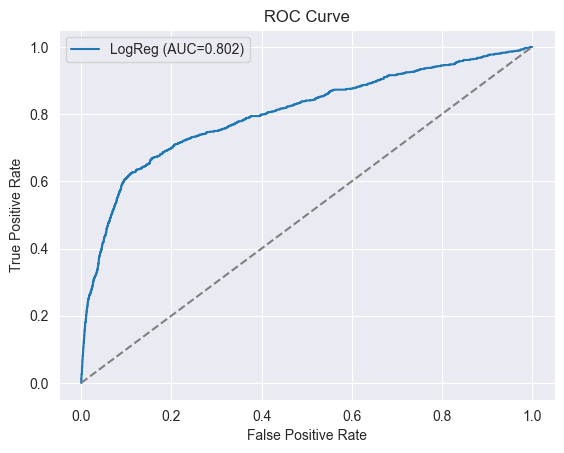

In [ ]:
# Logistic regression, training
log_reg = create_pipeline(
    model=LogisticRegression(
        max_iter=1000,
        C=1,
        class_weight='balanced'
        # solver='saga',
        # penalty='elasticnet',
        # l1_ratio=0.5,

    ),
    numeric_cols=num_features,
    categorical_cols=cat_features,
    scale_numeric=True,
    model_type='logistic'
)
log_reg.fit(X_train, y_train)

# comment on the results table
new_comment = 'Exp.17 + "education_clean"'

# evaluation of results
logreg_results = evaluate_model('LogReg', log_reg,
                                X_train, y_train,
                                X_val, y_val,
                                log_reg.get_params(),
                                new_comment, logreg_results)

In [ ]:
# saving and displaying the logreg_results table
save_results(logreg_results, '../outputs/logreg_results.csv')
logreg_results = pd.read_csv('../outputs/logreg_results.csv')
logreg_results

**Model quality comparison table** with different settings, Feature Engineering, etc.
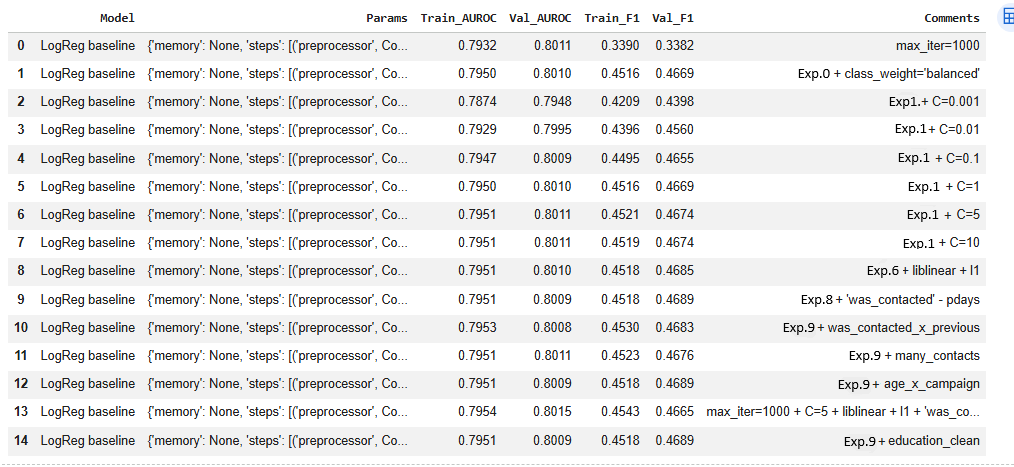


In [ ]:
# threshold tuning

y_val_proba = log_reg.predict_proba(X_val)[:, 1]

# threshold grid search
thresholds = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
thresholds_results = []

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_pred)
    thresholds_results.append({
        'Model': 'LogReg baseline',
        'Params': log_reg.get_params(),
        'Threshold': t,
        'Val_F1': f1
    })

thresholds_res = pd.DataFrame(thresholds_results)
thresholds_res.to_csv('../outputs/thresholds_res.csv', header=False, index=False)
thresholds_res

**Classification threshold selection results table**

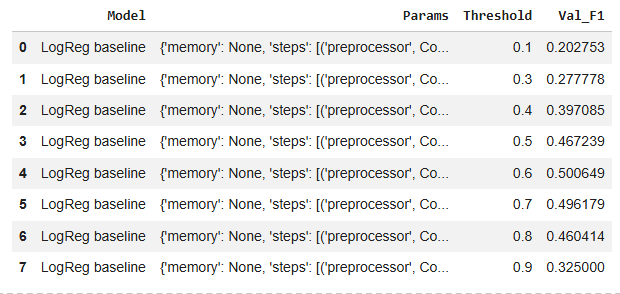

### **Conclusions:**
* Logistic regression model:
  - distinguishes classes quite well: Val AUROC ~ 0.80
  - identifies the positive class worse without threshold tuning:
      - f1_score ~ 0.47 at threshold = 0.5
      - f1_score ~ 0.50 at threshold = 0.6
* The greatest impact on model quality comes from:
   - parameter class_weight='balanced'
   - classification threshold tuning
* Feature Engineering (binary features, cleaning categorical variables, feature interaction, etc.) did not demonstrate significant changes
* Potential steps for further work:
   - removing "noisy" categories
   - creating polynomial features (however, there is a risk of overfitting due to a significant number of one-hot-encoded features)
   - grouping rare categories
   - using algorithms to combat class imbalance (SMOTETomek, ADASYN, etc.)

  However, since the model already shows fairly stable performance, new experiments may not yield a significant increase in quality.
* This model can subsequently be used as a baseline, and it is also convenient for interpreting feature impact on the target variable.

## kNN

In [ ]:
# data formation
train_knn = train_df.copy()
val_knn = val_df.copy()

input_cols_knn = [col for col in train_knn.columns if col not in ['y', 'y_num']]
drop_cols = ['duration', ]

In [ ]:
X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_knn,
    val_df=val_knn,
    input_cols=input_cols_knn,
    target_col=target_col,
    drop_cols=drop_cols)


In [ ]:
knn_preprocessor = create_preprocessor(num_features, cat_features)

X_train_processed = knn_preprocessor.fit_transform(X_train)

X_val_processed = knn_preprocessor.transform(X_val)

param_grid = {'n_neighbors': np.arange(1, 20)}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=10,
    refit=True
)

grid.fit(X_train_processed, y_train)

# best model
knn_best = grid.best_estimator_

# best parameters (k)
print('Best parameters:', grid.best_params_)


=== knn ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.66      0.21      0.31       928

    accuracy                           0.90      8238
   macro avg       0.79      0.60      0.63      8238
weighted avg       0.88      0.90      0.87      8238

Confusion matrix (validation):
[[7213   97]
 [ 737  191]]
Train AUROC: 0.8116
Validation AUROC: 0.7913


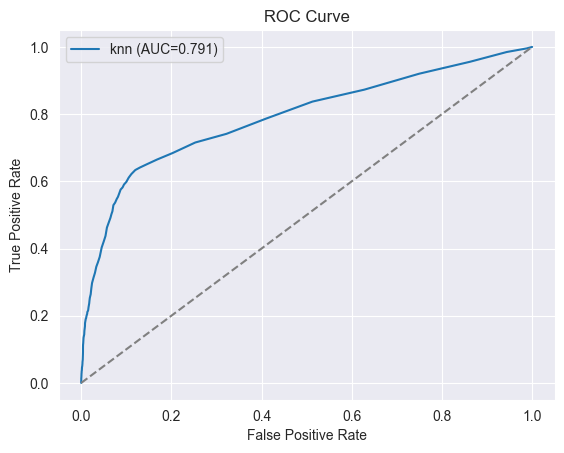

In [ ]:
# knn model
knn_model = create_pipeline(
    model=KNeighborsClassifier(
        n_neighbors=100,
        weights='uniform',  # 'distance' performed worse
        metric='euclidean'
    ),
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='knn',
    scale_numeric=True
)

# training
knn_model.fit(X_train, y_train)

# comment on the results table
new_comment = "n=100, weights='uniform', metric='euclidean'"

# evaluation of results
knn_results = evaluate_model('knn', knn_model,
                             X_train, y_train,
                             X_val, y_val,
                             knn_model.get_params(),
                             new_comment, knn_results)

In [ ]:
# saving and displaying the logreg_results table
save_results(knn_results, '../outputs/knn_results.csv')
knn_results = pd.read_csv('../outputs/knn_results.csv')
knn_results

**Model quality comparison table** with different settings

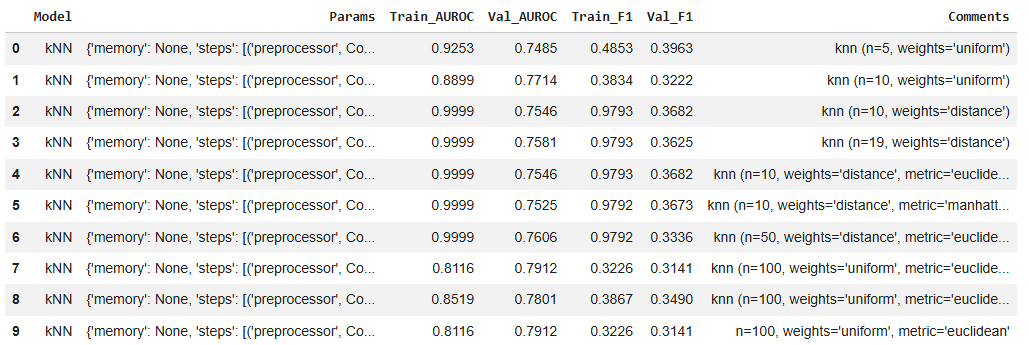

### **Conclusions**

kNN model:

  * achieved the best results (Val AUROC = 0.7912) with:
    - n_neighbors=100
    - weights='uniform'
    - metric='euclidean'
  * proved sensitive to hyperparameters and class imbalance: increasing n_neighbors reduces overfitting but lowers f1-score

  * poorly detects the minority class (f1-score across different settings ranges between 0.3141 - 0.3963)

* Potential next steps:
  - tuning the optimal value of n_neighbors
  - adjusting the classification threshold
  - balancing data with other methods (SMOTE() did not show significant changes)
  - selecting the most influential and removing "noisy" features
  - changing the scaling method (e.g., StandardScaler)

  However, since the model demonstrates relatively stable performance on Val AUROC, these approaches may not lead to significant improvements.

* The weak efficiency of the kNN algorithm for this task shows that its use is less appropriate compared to other algorithms.


## Decision Tree

In [ ]:
# data formation
train_dt = train_df.copy()
val_dt = val_df.copy()

input_cols_dt = [col for col in train_dt.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_dt,
    val_df=val_dt,
    input_cols=input_cols_dt,
    target_col=target_col,
    drop_cols=drop_cols)


=== tree ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.64      0.48       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238

Confusion matrix (validation):
[[6363  947]
 [ 332  596]]
Train AUROC: 0.7957
Validation AUROC: 0.8055


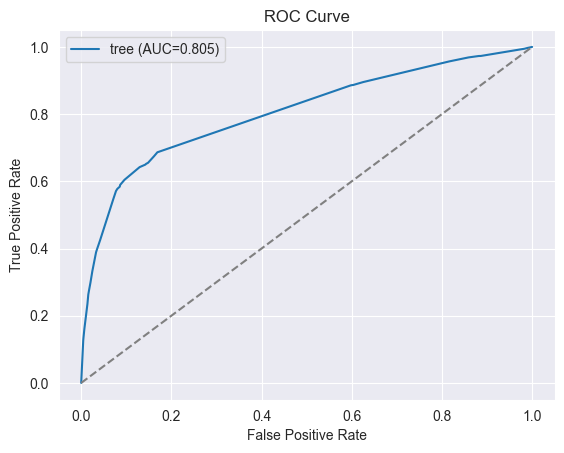

In [ ]:
# Decision Tree
dt_model = create_pipeline(
    model=DecisionTreeClassifier(
        random_state=42,
        max_depth=8,
        max_leaf_nodes=35,
        class_weight='balanced',
        min_samples_leaf=50,
        criterion='entropy'
    ),
    numeric_cols=num_features,
    categorical_cols=cat_features,
    scale_numeric=False,
    model_type='tree'
)

# training
dt_model.fit(X_train, y_train)

# comment on the results table
new_comment = "max_depth=8 + max_leaf_nodes=30 + class_weight='balanced  + min_samples_leaf=50 + criterion='entropy'"

# evaluation of results
dt_results = evaluate_model('tree', dt_model,
                            X_train, y_train,
                            X_val, y_val,
                            dt_model.get_params(),
                            new_comment, dt_results)

In [ ]:
# saving and displaying the logreg_results table
save_results(dt_results, '../outputs/dt_results.csv')
dt_results = pd.read_csv('../outputs/dt_results.csv')
dt_results

**Model quality comparison table** with different settings

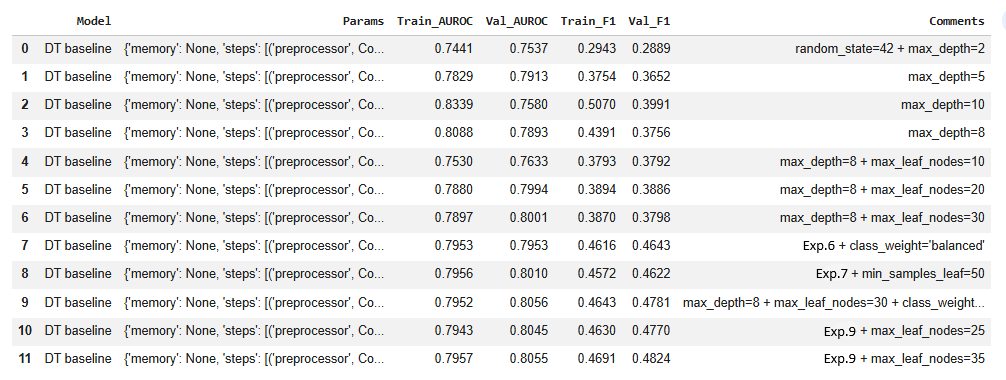



### **Conclusions**

DecisionTree model:

  * achieved the best results Val AUROC = 0.8056 with certain hyperparameter settings
  * showed better validation results than logistic regression or kNN: generalizes slightly better and more effectively identifies the minority class

* Potential next steps:
  - tuning optimal hyperparameters
  - adjusting the classification threshold
  - selecting the most influential and removing "noisy" features

* The model can be used as a baseline, as well as for interpretation and visualization


## XGBoost

### Baseline model

In [ ]:
# data formation
train_xgbm = train_df.copy()
val_xgbm = val_df.copy()

input_cols_xgbm = [col for col in train_xgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_xgbm,
    val_df=val_xgbm,
    input_cols=input_cols_xgbm,
    target_col=target_col,
    drop_cols=drop_cols)


=== xgbm ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.24      0.35       928

    accuracy                           0.90      8238
   macro avg       0.80      0.61      0.65      8238
weighted avg       0.89      0.90      0.88      8238

Confusion matrix (validation):
[[7212   98]
 [ 709  219]]
Train AUROC: 0.8193
Validation AUROC: 0.8150


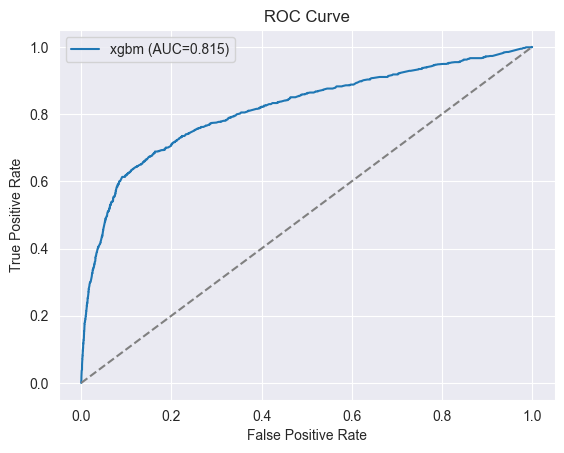

In [ ]:
# XGBClassifie
xgbm_model = create_pipeline(
    model=XGBClassifier(
        n_estimators=10,
        max_depth=5,

        # learning_rate=0.03,
        # scale_pos_weight=7,
        # subsample=0.8,           # fraction of rows for each tree

        # reg_lambda=1,            # L2 regularization
        # reg_alpha=0,              # L1 regularization

        # device='cuda',
        # verbosity=0,

        random_state=42,
        use_label_encoder=False,
        missing=np.nan),

    numeric_cols=num_features,
    categorical_cols=cat_features,
    scale_numeric=False,
    model_type='xgbm'
)
xgbm_model.fit(X_train, y_train)

# comment on the results tabl
new_comment = 'n_estimators=10 + max_depth=5'

# evaluation of results
xgbm_results = evaluate_model('xgbm', xgbm_model,
                              X_train, y_train,
                              X_val, y_val,
                              xgbm_model.get_params(),
                              new_comment, xgbm_results)

In [ ]:
# saving and displaying the logreg_results table
save_results(xgbm_results, '../outputs/xgbm_results.csv')
xgbm_results = pd.read_csv('../outputs/xgbm_results.csv')
xgbm_results

**Best XGBM result with manual parameter settings:**

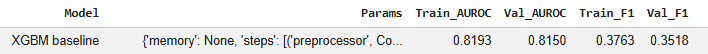



### RandomizedSearchCV

In [ ]:
# data formation
train_xgbm = train_df.copy()
val_xgbm = val_df.copy()

input_cols_xgbm = [col for col in train_xgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_xgbm,
    val_df=val_xgbm,
    input_cols=input_cols_xgbm,
    target_col=target_col,
    drop_cols=drop_cols)



=== XGBM random search ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.46      0.62      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.88      8238

Confusion matrix (validation):
[[6649  661]
 [ 355  573]]
Train AUROC: 0.8276
Validation AUROC: 0.8150


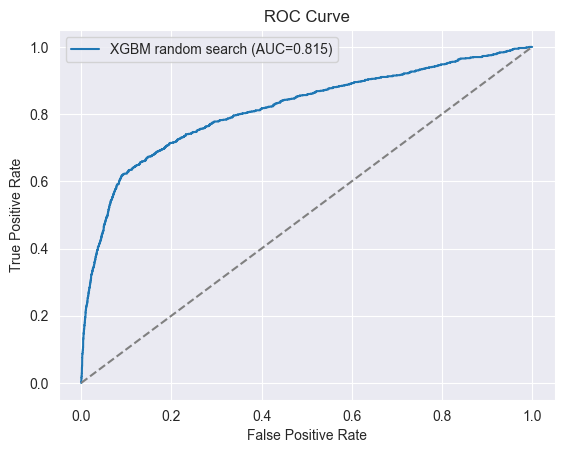

In [ ]:
# model with basic technical settings
xgb_base = XGBClassifier(
    random_state=42,
    use_label_encoder=False)

pipeline_for_search = create_pipeline(
    model=xgb_base,
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='xgbm',
    scale_numeric=True)

# parameter grid
param_dist = {
    'model__n_estimators': [500, 800],
    'model__learning_rate': [0.01, 0.05],
    'model__max_depth': [3, 4, 5],
    'model__scale_pos_weight': [5, 6, 7],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

# parameter search
random_search = RandomizedSearchCV(
    estimator=pipeline_for_search,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=20,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# comment on the results table
new_comment = 'Best combination after Randomized Search'

# evaluation of results
xgbm_results = evaluate_model(
    'XGBM random search',
    random_search.best_estimator_,
    X_train, y_train,
    X_val, y_val,
    random_search.best_params_,
    new_comment, xgbm_results
)

In [ ]:
# saving and displaying the logreg_results table
save_results(xgbm_results, '../outputs/xgbm_results.csv')
xgbm_results = pd.read_csv('../outputs/xgbm_results.csv')
xgbm_results

**Best XGBM result after Randomized Search:**


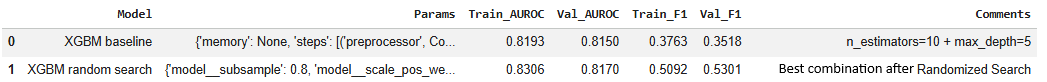

### Bayesian Optimization

In [ ]:
# data formation
train_xgbm = train_df.copy()
val_xgbm = val_df.copy()

input_cols_xgbm = [col for col in train_xgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_xgbm,
    val_df=val_xgbm,
    input_cols=input_cols_xgbm,
    target_col=target_col,
    drop_cols=drop_cols)


In [ ]:
def objective(params):
    xgb_params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': params['learning_rate'],
        'scale_pos_weight': params['scale_pos_weight'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'random_state': 42,
        'use_label_encoder': False,
        'n_jobs': -1
    }

    hyperopt_model = XGBClassifier(**xgb_params)

    hyperopt_pipeline = create_pipeline(
        model=hyperopt_model,
        numeric_cols=num_features,
        categorical_cols=cat_features,
        model_type='xgbm'
    )

    score = cross_val_score(hyperopt_pipeline, X_train, y_train, cv=5, scoring='roc_auc').mean()

    return {'loss': -score, 'status': STATUS_OK}

In [ ]:
# space = {
#     'n_estimators': hp.quniform('n_estimators', 100, 1000, 50), # from 100 to 1000 with a step of 50
#     'max_depth': hp.quniform('max_depth', 3, 10, 1),           # from 3 to 10
#     'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
#     'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
#     'subsample': hp.uniform('subsample', 0.6, 1.0),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0)
# }

# space = {
#     'n_estimators': hp.quniform('n_estimators', 400, 1000, 50),
#     'max_depth': hp.quniform('max_depth', 3, 6, 1),
#     'learning_rate': hp.uniform('learning_rate', 0.01, 0.05),
#     'scale_pos_weight': hp.uniform('scale_pos_weight', 5, 8),
#     'subsample': hp.uniform('subsample', 0.7, 0.9),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 0.9),
#     'gamma': hp.uniform('gamma', 0.1, 0.5),
#     'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1)
# }


# space = {
#     'n_estimators': hp.quniform('n_estimators', 400, 1200, 50),
#     'max_depth': hp.quniform('max_depth', 3, 5, 1),
#     'learning_rate': hp.uniform('learning_rate', 0.005, 0.03),
#     'scale_pos_weight': hp.uniform('scale_pos_weight', 5.5, 7.5),
#     'subsample': hp.uniform('subsample', 0.6, 0.8),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 0.8),
#     'reg_alpha': hp.uniform('reg_alpha', 0.1, 10),             # L1
#     'reg_lambda': hp.uniform('reg_lambda', 1, 10),             # L2
#     'gamma': hp.uniform('gamma', 0.2, 1.0),
#     'min_child_weight': hp.quniform('min_child_weight', 5, 20, 1)
# }

space = {
    'n_estimators': hp.quniform('n_estimators', 300, 900, 50),

    'max_depth': hp.quniform('max_depth', 3, 7, 1),

    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.1)),

    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),

    'min_child_weight': hp.quniform('min_child_weight', 1, 8, 1),

    'gamma': hp.uniform('gamma', 0, 0.4),

    'reg_alpha': hp.uniform('reg_alpha', 0, 3),
    'reg_lambda': hp.uniform('reg_lambda', 1, 5),

    'scale_pos_weight': hp.uniform('scale_pos_weight', 3, 8)
}

In [ ]:
# object to store trial history
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)
)

print('Best parameters:', best)

In [ ]:
import json

# saving
with open("../models/best_params.json", "w", encoding="utf-8") as f:
    json.dump(best, f, indent=4)

In [ ]:
import json
# loading
with open("../models/best_params.json", "r", encoding="utf-8") as f:
    best = json.load(f)


=== XGBM Hyperopt ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7310
           1       0.48      0.58      0.52       928

    accuracy                           0.88      8238
   macro avg       0.71      0.75      0.73      8238
weighted avg       0.89      0.88      0.89      8238

Confusion matrix (validation):
[[6734  576]
 [ 393  535]]
Train AUROC: 0.8151
Validation AUROC: 0.8139


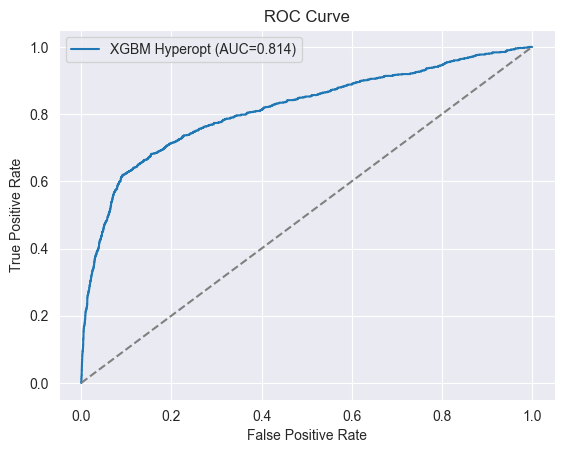

In [ ]:
# preparing parameters
best_params = {
    'n_estimators': int(best['n_estimators']),
    'max_depth': int(best['max_depth']),
    'learning_rate': best['learning_rate'],
    'colsample_bytree': best['colsample_bytree'],
    'subsample': best['subsample'],
    'scale_pos_weight': best['scale_pos_weight'],
    'random_state': 42,
    'use_label_encoder': False
}

# final pipeline with the best parameters
final_xgb = XGBClassifier(**best_params)

final_xgb_pipeline = create_pipeline(
    model=final_xgb,
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='xgbm'
)

final_xgb_pipeline.fit(X_train, y_train)

# comment on the results table
new_comment = 'Bayesian Optimization (Hyperopt)- 4'

# evaluation of results
xgbm_results = evaluate_model(
    'XGBM Hyperopt',
    final_xgb_pipeline,
    X_train, y_train,
    X_val, y_val,
    best_params,
    new_comment,
    xgbm_results
)

In [ ]:
# saving and displaying the logreg_results table
save_results(xgbm_results, '../outputs/xgbm_results.csv')
xgbm_results = pd.read_csv('../outputs/xgbm_results.csv')
xgbm_results


**Best XGBM result after Bayesian Optimization:**


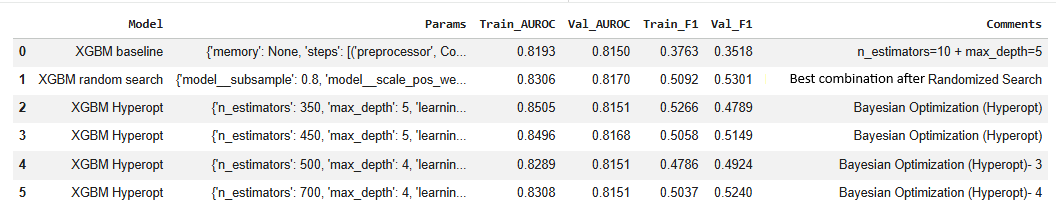

### **Conclusions**
* The baseline XGBM model demonstrated a Val_AUROC = 0.8150 result, which indicates fairly good generalization properties, but still a not very high-quality extraction of the minority class: f1-score = 0.3518.

* Using Randomized Search made it possible to find parameters that slightly improved Val_AUROC (=0.8170) and significantly increased f1-score to 0.5301.

* Hyperparameter tuning using Bayesian Optimization (Hyperopt) did not yield significant improvement compared to Randomized Search: Val_AUROC decreased slightly, while the f1-score fluctuates in the range of 0.4789–0.5240. The results are better than those of the baseline XGBM model.

* To further improve the model, feature engineering and classification threshold tuning can be applied.

* Overall, the XGBM model demonstrated:
  - the best results among all previous models, even with baseline settings
  - a stable Val_AUROC and the highest f1-score (when using Randomized Search)

## LightGBM

### Base model

In [ ]:
# data formation
train_lgbm = train_df.copy()
val_lgbm = val_df.copy()

In [ ]:
# Experiments with Feature Engineering

# for df in [train_lgbm, val_lgbm]:
# # whether there was previous contact with the client (999 - no contact)
# df['new_customer'] = (df['pdays'] == 999).astype(int)

# # ratio of current campaign contacts to previous ones
# df['campaign_ratio'] = df['campaign'] / (df['previous'] + 1)

# # successful result in the past
# df['prev_success'] = (df['poutcome'] == 'success').astype(int)


# # consumer price and confidence index
# df['eco_index'] = df['cons.price.idx'] * df['cons.conf.idx']

# # "risky" clients
# df['is_high_risk'] = ((df['job'].isin(['unemployed', 'unknown'])) |
#                       (df['education'] == 'illiterate')).astype(int)


# # # contact intensity
# df['high_contact_intensity'] = (df['campaign'] > 5).astype(int)

# # first contact
# df['is_first_contact'] = (df['campaign'] == 1).astype(int)

# df['is_student_or_retired'] = df['job'].isin(['student', 'retired']).astype(int)

# df['has_high_education'] = (df['education'] == 'university.degree').astype(int)

# # single client
# df['is_single'] = (df['marital'] == 'single').astype(int)


# # there was contact and it was successful
# df['high_interest_client'] = (
#     (df['previous'] > 0) & (df['poutcome'] == 'success')
# ).astype(int)

# # low rate
# df['low_interest_rate'] = (df['euribor3m'] < 2).astype(int)

In [ ]:
input_cols_lgbm = [col for col in train_lgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_lgbm,
    target_col=target_col,
    drop_cols=drop_cols)

In [ ]:
# LightGBM

# baseline: random_state=42, n_estimators=100, learning_rate=0.1, max_depth=-1,

lgbm_model = create_pipeline(
    model=LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.05,
        max_depth=-1,
        is_unbalance=True,
        num_leaves=31,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=0.1
    ),

    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='lightgbm',
)

lgbm_model.fit(X_train, y_train)




=== LightGBM ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.88      0.92      7310
           1       0.41      0.66      0.51       928

    accuracy                           0.86      8238
   macro avg       0.68      0.77      0.71      8238
weighted avg       0.89      0.86      0.87      8238

Confusion matrix (validation):
[[6441  869]
 [ 316  612]]
Train AUROC: 0.8536
Validation AUROC: 0.8208


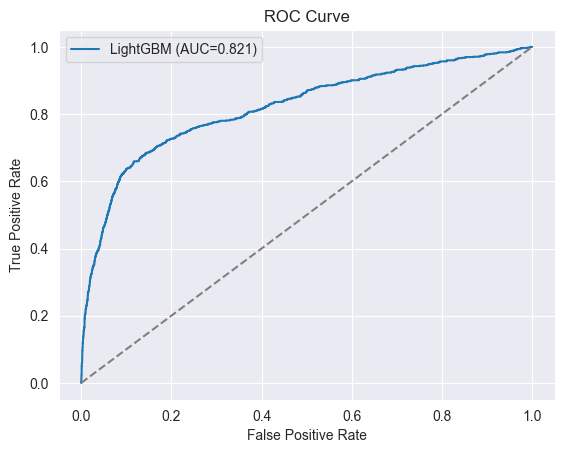

In [ ]:
# comment on the results table
new_comment = "Exp.3 + drop'loan'"

# evaluation of results
lgbm_results = evaluate_model(
    model_name='LightGBM',
    model=lgbm_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    params=lgbm_model.get_params(),
    comments=new_comment,
    results_table=lgbm_results
)

In [ ]:
# saving and displaying the logreg_results table
save_results(lgbm_results, '../outputs/lgbm_results.csv')
lgbm_results = pd.read_csv('../outputs/lgbm_results.csv')
lgbm_results

**Best LightGBM result with manual hyperparameter tuning:**

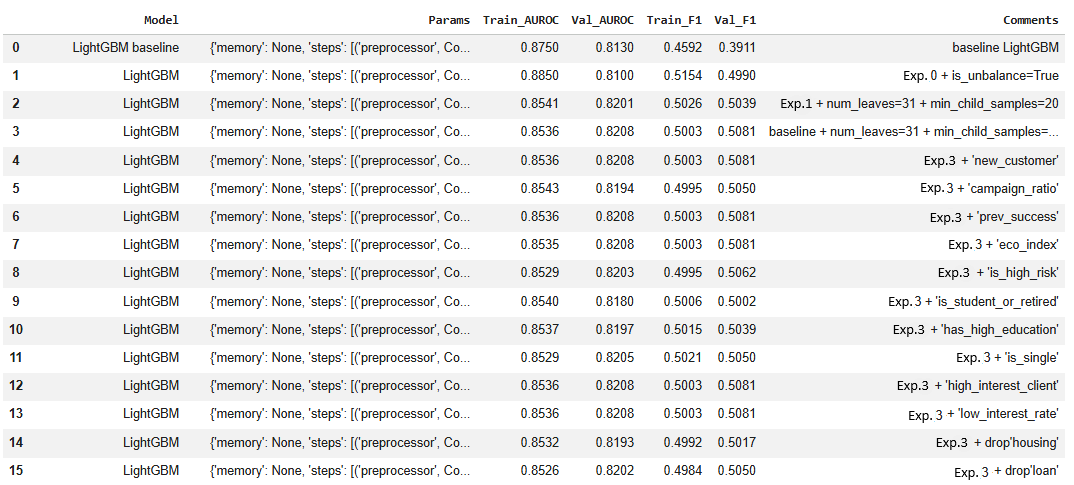

### Randomized Search

In [ ]:
# data formation
train_lgbm = train_df.copy()
val_lgbm = val_df.copy()

input_cols_lgbm = [col for col in train_lgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_lgbm,
    target_col=target_col,
    drop_cols=drop_cols)


=== LightGBM random search ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7310
           1       0.43      0.64      0.52       928

    accuracy                           0.86      8238
   macro avg       0.69      0.77      0.72      8238
weighted avg       0.89      0.86      0.88      8238

Confusion matrix (validation):
[[6529  781]
 [ 332  596]]
Train AUROC: 0.8338
Validation AUROC: 0.8198


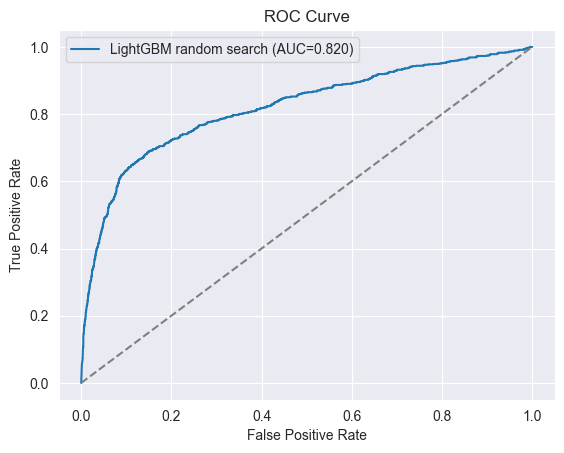

In [ ]:
# base model
lgbm_base = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

pipeline_lgbm_search = create_pipeline(
    model=lgbm_base,
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='lightgbm',
    scale_numeric=True
)

# parameter grid
# param_dist_lgbm = {
#     'model__n_estimators': [100, 500, 1000],
#     'model__learning_rate': [0.01, 0.05, 0.1],
#     'model__num_leaves': [20, 31, 60],
#     'model__max_depth': [-1, 5, 10],
#     'model__min_child_samples': [10, 20, 50],
#     'model__is_unbalance': [True],
#     'model__reg_alpha': [0, 0.1, 0.5],
#     'model__reg_lambda': [0, 0.1, 0.5]
# }

param_dist_lgbm = {
    # Ratio of speed and number of iterations
    'model__n_estimators': [500, 1000, 1500],
    'model__learning_rate': [0.005, 0.01, 0.05],

    'model__num_leaves': [15, 31, 63, 127],
    'model__max_depth': [-1, 5, 7, 9],
    'model__min_child_samples': [20, 50, 100],
    'model__reg_alpha': [0, 0.1, 1.0, 10.0],  # L1
    'model__reg_lambda': [0, 0.1, 1.0, 10.0],  # L2

    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__subsample': [0.7, 0.8, 0.9],

    'model__is_unbalance': [True]
}

# search
random_search_lgbm = RandomizedSearchCV(
    estimator=pipeline_lgbm_search,
    param_distributions=param_dist_lgbm,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

# comment on the results table
new_comment = 'Result after Randomized Search'

# evaluation of results
lgbm_results = evaluate_model(
    "LightGBM random search",
    random_search_lgbm.best_estimator_,
    X_train, y_train,
    X_val, y_val,
    random_search_lgbm.best_params_,
    new_comment,
    lgbm_results
)

In [ ]:
# saving and displaying the logreg_results table
save_results(lgbm_results, '../outputs/lgbm_results.csv')
lgbm_results = pd.read_csv('../outputs/lgbm_results.csv')
lgbm_results

**Best LightGBM result after Random Search:**

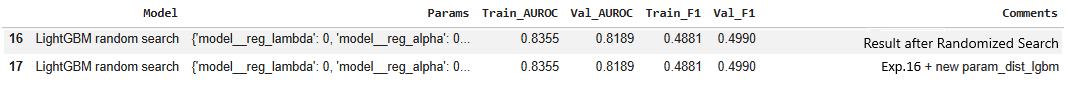

### Bayesian Optimization

In [ ]:
# data formation
train_lgbm = train_df.copy()
val_lgbm = val_df.copy()

input_cols_lgbm = [col for col in train_lgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_lgbm,
    target_col=target_col,
    drop_cols=drop_cols)

In [ ]:
def objective(params):
    lgbm_params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'num_leaves': int(params['num_leaves']),
        'min_child_samples': int(params['min_child_samples']),
        'learning_rate': params['learning_rate'],
        'colsample_bytree': params['colsample_bytree'],
        'subsample': params['subsample'],
        'subsample_freq': int(params['subsample_freq']),
        'min_split_gain': params['min_split_gain'],
        'reg_alpha': params['reg_alpha'],
        'reg_lambda': params['reg_lambda'],
        'scale_pos_weight': params['scale_pos_weight'],

        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1,
    }

    hyperopt_model = LGBMClassifier(**lgbm_params)

    hyperopt_pipeline = create_pipeline(
        model=hyperopt_model,
        numeric_cols=num_features,
        categorical_cols=cat_features,
        model_type='lightgbm'
    )

    score = cross_val_score(hyperopt_pipeline, X_train, y_train, cv=10, scoring='roc_auc').mean()

    return {'loss': -score, 'status': STATUS_OK}

In [ ]:
# # hyperparameter search space
# space = {
#     'n_estimators': hp.quniform('n_estimators', 300, 1000, 50),
#     'max_depth': hp.quniform('max_depth', 3, 10, 1),
#     'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
#     'learning_rate': hp.loguniform('learning_rate', np.log(0.005), np.log(0.1)),
#     'subsample': hp.uniform('subsample', 0.6, 1.0),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
#     'min_child_samples': hp.quniform('min_child_samples', 5, 50, 5),
#     'reg_alpha': hp.uniform('reg_alpha', 0, 10),
#     'reg_lambda': hp.uniform('reg_lambda', 0, 10)
# }


space = {
    'n_estimators': hp.quniform('n_estimators', 300, 1500, 50),
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'num_leaves': hp.quniform('num_leaves', 15, 100, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.003), np.log(0.1)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'subsample_freq': hp.quniform('subsample_freq', 1, 10, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_samples': hp.quniform('min_child_samples', 5, 50, 5),
    'min_split_gain': hp.uniform('min_split_gain', 0.0, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 10),
    'reg_lambda': hp.uniform('reg_lambda', 0, 10),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 5, 15)
}

In [ ]:
# object for storing the history of all attempts
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=40,  # increased to 40 so Bayes has time to "learn"
    trials=trials,
    rstate=np.random.default_rng(42)
)

print('Best parameters:', best)

In [ ]:
with open("../models/best_params_lgbm.json", "w", encoding="utf-8") as f:
    json.dump(best, f, indent=4)

In [ ]:
import json
# loading
with open("../models/best_params_lgbm.json", "r", encoding="utf-8") as f:
    best = json.load(f)

In [ ]:
# parameters preparation
best_params = {
    'n_estimators': int(best['n_estimators']),
    'max_depth': int(best['max_depth']),
    'num_leaves': int(best['num_leaves']),
    'learning_rate': best['learning_rate'],
    'colsample_bytree': best['colsample_bytree'],
    'subsample': best['subsample'],
    'min_child_samples': int(best['min_child_samples']),
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda'],
    'is_unbalance': True,
    'random_state': 42
}

# final pipeline
final_lgbm = LGBMClassifier(**best_params)

final_lgbm_pipeline = create_pipeline(
    model=final_lgbm,
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='lightgbm'
)

final_lgbm_pipeline.fit(X_train, y_train)


=== LGBM Hyperopt ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.66      0.49       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238

Confusion matrix (validation):
[[6343  967]
 [ 317  611]]
Train AUROC: 0.8304
Validation AUROC: 0.8174


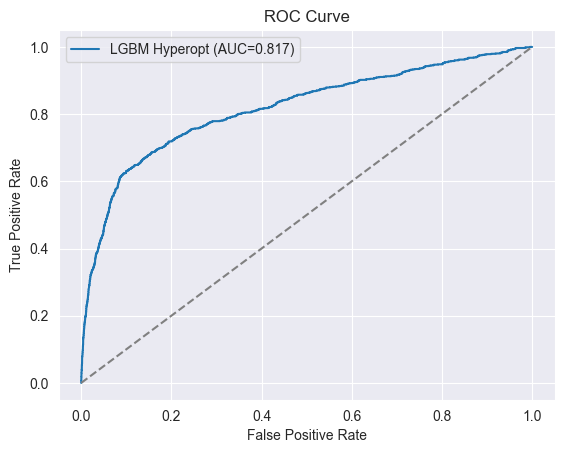

In [ ]:
# comment on the results table
new_comment = 'Bayesian Optimization + new space'

# evaluation of results
lgbm_results = evaluate_model(
    'LGBM Hyperopt',
    final_lgbm_pipeline,
    X_train, y_train,
    X_val, y_val,
    best_params,
    new_comment,
    lgbm_results
)

In [ ]:
# saving and displaying the logreg_results table
save_results(lgbm_results, '../outputs/lgbm_results.csv')
lgbm_results = pd.read_csv('../outputs/lgbm_results.csv')
lgbm_results

**Best LightGBM result after Bayesian Optimization:**

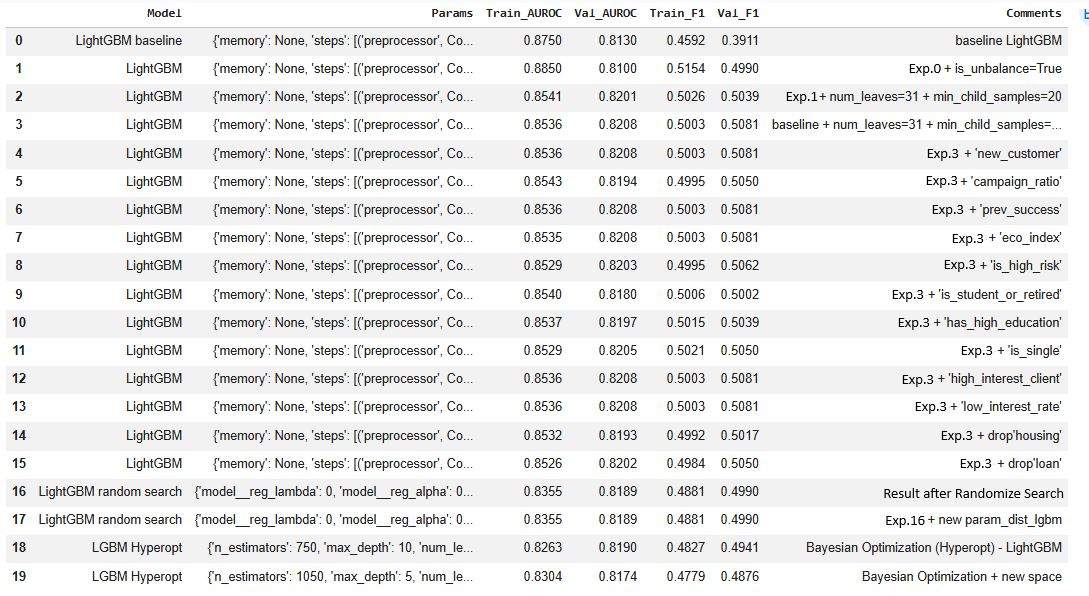

### **Conclusions**
* The baseline LightGBM model with basic settings demonstrated a result of Val_AUROC = 0.8208, which indicates fairly good generalization properties, minority class identification is also better than previous models: f1-score = 0.5081.

* The use of Randomized Search and Bayesian Optimization for hyperparameter search did not demonstrate significant changes, which indicates stable operation of the model.

* To further improve the model, you can try feature engineering and selecting the classification threshold

* The LightGBM model demonstrated:
  -  the best results among all previous models even with basic settings
  - stable  Val_AUROC and the highest f1-score

## General summary table of model performance main_results

For each algorithm, the model with the best metric value on the validation set was selected. The resulting models are summarized in an overview table for further comparison.

In [ ]:
# the best results among all models
best_logreg = logreg_results.loc[logreg_results['Val_AUROC'].idxmax()]
best_knn = knn_results.loc[knn_results['Val_AUROC'].idxmax()]
best_dt = dt_results.loc[dt_results['Val_AUROC'].idxmax()]
best_xgbm = xgbm_results.loc[xgbm_results['Val_AUROC'].idxmax()]
best_lgbm = lgbm_results.loc[lgbm_results['Val_AUROC'].idxmax()]

# main results table
main_results = pd.DataFrame([best_logreg, best_knn, best_dt, best_xgbm, best_lgbm])
main_results = main_results.reset_index(drop=True)

main_results

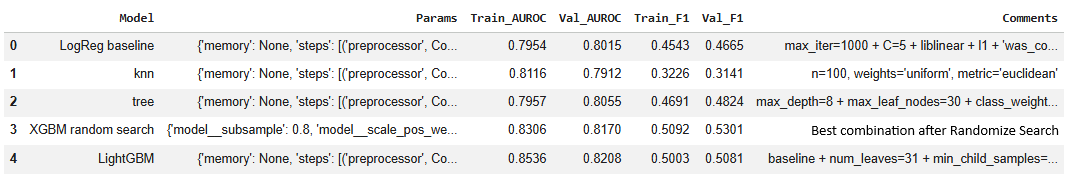

Given that AUROC was chosen as the primary evaluation metric, the **LightGBM** model was selected as the final one.